In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import cv2
import numpy as np
from PIL import Image

# 폰트 설정
font_path = 'C:\Windows\Fonts\gulim.ttc' 
fontprop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fontprop.get_name()

In [8]:
# 이미지 전처리 함수
def preprocess(image):
   image = np.array(image)

   # 1. 이미지 크기 조정
   image = cv2.resize(image, (224, 224))

   # 2. CLAHE 적용 (대비 향상)
   #lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)  # 이미지를 RGB에서 LAB 색 공간으로 변환
   #l, a, b = cv2.split(lab)                      # LAB 이미지에서 L(밝기), A(색상 정보), B(색상 정보) 채널을 분리
   #clahe = cv2.createCLAHE(
   #   clipLimit=2.0, tileGridSize=(8, 8)
   #)                                             # 이미지 블록을 8x8로 나눠서 각 블록에 대해 히스토그램 평활화 적용
   #l = clahe.apply(l)                            # 명도 정보를 부분별로 보정해, 어두운 곳은 더 밝게, 밝은 곳은 더 어둡게 보정
   #lab = cv2.merge((l, a, b))                    # CLAHE가 적용된 l 채널과 원래의 a, b 채널을 다시 합쳐서 LAB 이미지
   #image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

   # 3. 샤프닝 필터 정의 (일반적인 샤프닝 커널)
   mask = np.asarray([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype = np.float32)
   image = cv2.filter2D(image, -1, mask)

   # 4. 이미지 정규화
   image = image.astype(np.float32) / 255.0

   # 5. 배치 차원 추가
   # 모델의 입력은 batch 단위로 처리되기 때문에, 
   # 단일 이미지를 모델에 전달하려면 batch_size=1로 설정해줘야 합니다.
   # 모델이 여러 개의 샘플을 처리하는 방식을 기대하는데, 
   # 단일 이미지 데이터를 제공하면 오류가 발생할 수 있습니다.
   # (224, 224, 3) -> (1, 224, 224, 3) 
   # image = np.expand_dims(image, axis=0)
   return image


0: 640x640 1 apple, 351.2ms
Speed: 4.3ms preprocess, 351.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


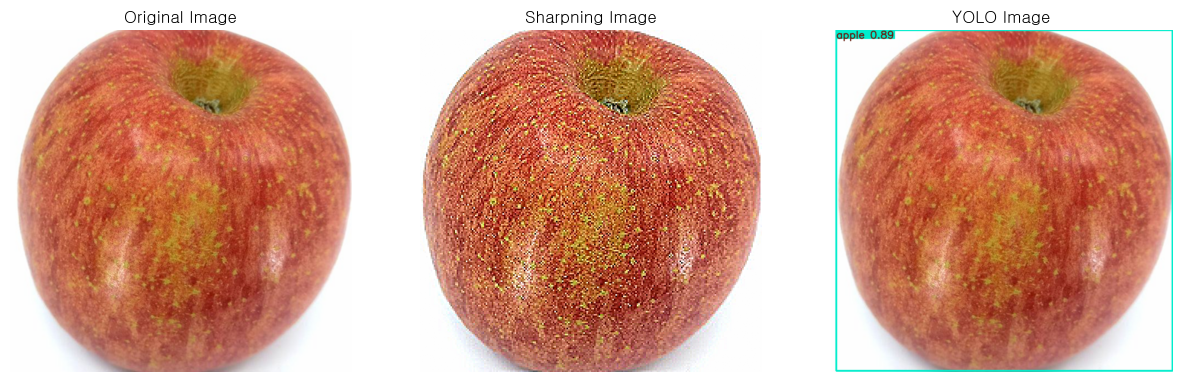

In [42]:
from ultralytics import YOLO

# YOLO 모델로 객체 인식 수행
def yolo_detect(model, img, target_class_id):
   # 이미지가 PIL 이미지인 경우 numpy 배열로 변환
   img_np = np.array(img) if isinstance(img, Image.Image) else img
   results = model.predict(img_np)

   extracted_obj = []
   # 결과에서 바운딩 박스 정보 가져오기
   for result in results:
      # 바운딩 박스 정보가 사과(47)인 경우에만 박스 추출
      for box, cls in zip(result.boxes, result.boxes.cls):
         if int(cls) == target_class_id:
            # 이미지에서 객체 영역 자르기
            x1, y1, x2, y2 = map(int, box.xyxy[0])  # xyxy 형식의 좌표
            cropped_obj = img_np[y1:y2, x1:x2]
            extracted_obj.append(cropped_obj)

   return extracted_obj, results

img_file_path = './apple_fuji_L_26-77.png'
model = YOLO('yolov8m.pt')

try:
   with Image.open(img_file_path) as img:
      img_np = np.array(img)
      img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
      img_yolo, result_yolo = yolo_detect(model, img, 47)
      img_sharp = preprocess(img_yolo[0])
   
   # 시각화
   plt.figure(figsize=(15, 5))  # 원하는 크기로 수정 가능

   # 원본 이미지
   plt.subplot(1, 3, 1)
   plt.imshow(img)
   plt.title('Original Image')
   plt.axis('off')

   # YOLO 이미지
   plt.subplot(1, 3, 3)
   plt.imshow(result_yolo[0].plot())
   plt.title('YOLO Image')
   plt.axis('off')

   # 샤프닝된 이미지
   plt.subplot(1, 3, 2)
   plt.imshow(img_sharp)
   plt.title('Sharpning Image')
   plt.axis('off')

except Exception as e:
   print(f'오류 발생: {e}')